# PRÁCTICA 3: CLUSTERING DE UNA IMAGEN


### EJERCICIO 1. Representacion de la Imagen en el Espacio RGB

Píxeles RGB: (406272, 3)
Primeros 10 píxeles RGB:
 [[133 144 104]
 [121 132  92]
 [135 147 109]
 [113 125  87]
 [122 136 100]
 [127 141 105]
 [102 116  80]
 [ 79  93  57]
 [ 63  78  39]
 [ 46  61  22]]


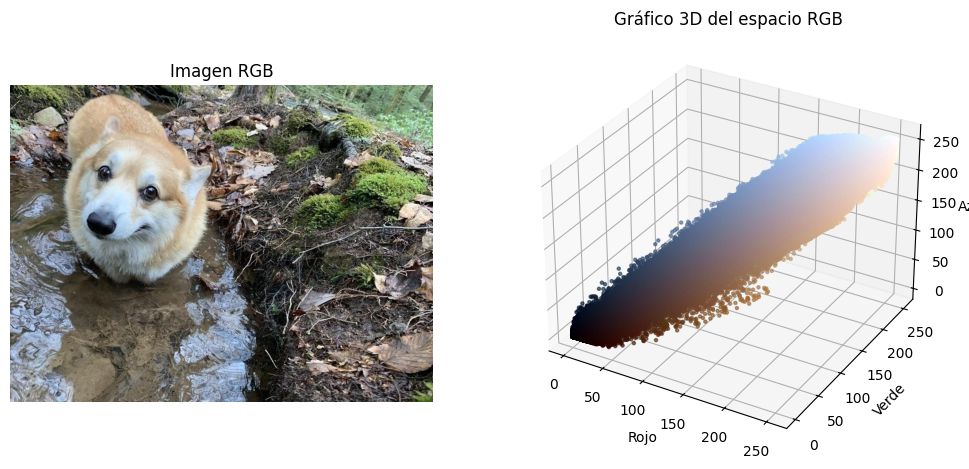

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

ruta = "/content/drive/MyDrive/PDI/perrito.jpeg"

# Carga de imagen
img = cv2.imread(ruta)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Extracción de valores RGB en cada píxel
pixeles = img_rgb.reshape(-1, 3)
print("Píxeles RGB:", pixeles.shape)
print("Primeros 10 píxeles RGB:\n", pixeles[:10])

# Crear figura grande
plt.figure(figsize=(12,8))

# Visualización de la imagen
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Imagen RGB')
plt.axis('off')

# Gráfico 3D del espacio RGB
ax = plt.subplot(1,2,2, projection='3d')
r, g, b = pixeles[:, 0], pixeles[:, 1], pixeles[:, 2]
ax.scatter(r, g, b, c=pixeles/255.0, marker='o', s=5, alpha=0.6)
ax.set_xlabel('Rojo')
ax.set_ylabel('Verde')
ax.set_zlabel('Azul')
ax.set_title('Gráfico 3D del espacio RGB')

plt.show()

### EJERCICIO 2. Segmentacion con K-means

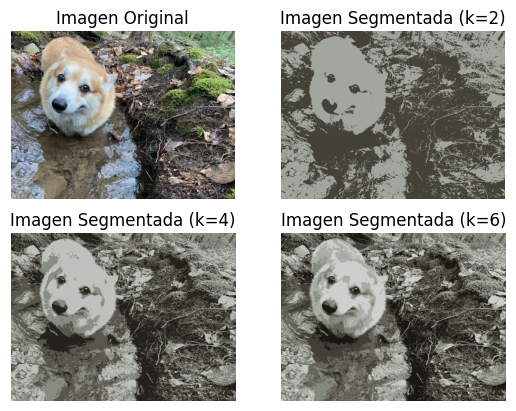

In [5]:
# Segmentación de la imagen con algoritmo k-medias
kmeans = KMeans(n_clusters=2, random_state=50)
kmeans.fit(pixeles)
labels = kmeans.labels_
centros = kmeans.cluster_centers_.astype(np.uint8)
img_segk2 = centros[labels].reshape(img_rgb.shape)

kmeans = KMeans(n_clusters=4, random_state=50)
kmeans.fit(pixeles)
labels = kmeans.labels_
centros = kmeans.cluster_centers_.astype(np.uint8)
img_segk4 = centros[labels].reshape(img_rgb.shape)

kmeans = KMeans(n_clusters=6, random_state=50)
kmeans.fit(pixeles)
labels = kmeans.labels_
centros = kmeans.cluster_centers_.astype(np.uint8)
img_segk6 = centros[labels].reshape(img_rgb.shape)

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_segk2)
plt.title('Imagen Segmentada (k=2)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_segk4)
plt.title('Imagen Segmentada (k=4)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_segk6)
plt.title('Imagen Segmentada (k=6)')
plt.axis('off')

plt.show()

### EJERCICIO 3. Aplicacion Practica

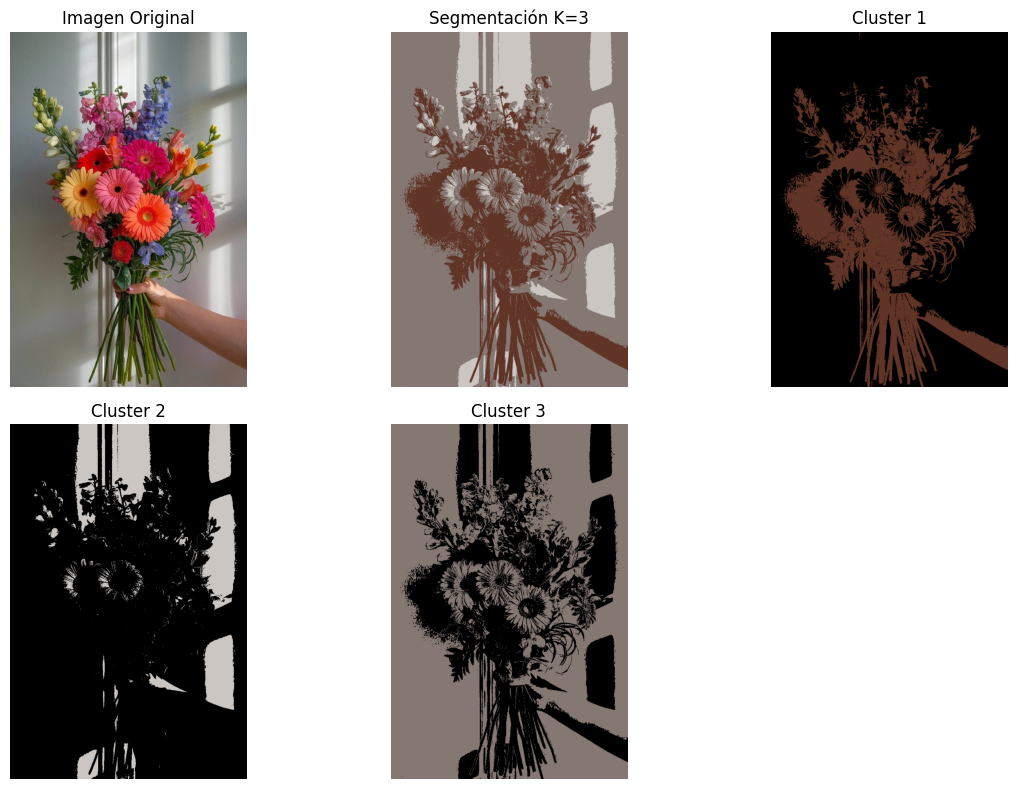

In [9]:
ruta = "/content/drive/MyDrive/PDI/flores.jpeg"

# CARGAR IMAGEN
img = cv2.imread(ruta)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rows, cols = img_rgb.shape[:2]

# PREPARAR DATOS PARA K-MEANS
pixeles = img_rgb.reshape((-1, 3))
pixeles = np.float32(pixeles)

# APLICAR k=3
k = 3
criterios = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

_, labels, centers = cv2.kmeans(pixeles,
                                k,
                                None,
                                criterios,
                                10,
                                cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)

# Reconstruir imagen segmentada
segmentada = centers[labels.flatten()]
segmentada = segmentada.reshape((img_rgb.shape))

plt.figure(figsize=(12,8))

# Imagen original
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Imagen Original")
plt.axis("off")

# Imagen segmentada
plt.subplot(2,3,2)
plt.imshow(segmentada)
plt.title("Segmentación K=3")
plt.axis("off")

# Mostrar cada cluster por separado
for i in range(k):
    cluster = np.zeros_like(pixeles)
    cluster[labels.flatten() == i] = centers[i]
    cluster_img = cluster.reshape(img_rgb.shape).astype(np.uint8)

    plt.subplot(2,3,3+i)
    plt.imshow(cluster_img)
    plt.title(f"Cluster {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()